# IT Incident SLA Prediction – Final Report Notebook
## IST 660 – Data Mining & Business Intelligence
### Team 1

---

**Business question:** At ticket open time, can we identify incidents that are likely to miss SLA so that service desk managers can intervene earlier?

**Dataset structure note:** The raw input file is an **event-level incident log**, not an incident-level file. Each incident (identified by `number`) appears in multiple rows — one row per state change or update event. The final modeling dataset is built at the incident level, with **one row per incident** (24,918 incidents total).

**Key methodological points addressed in this notebook:**
1. `"?"` is treated as the real missing-value placeholder (not `isna()` alone).
2. `made_sla` is **not stable** across all rows for the same incident — the SLA outcome can differ across rows within the same incident. We document this and justify our target definition.
3. Predictors come from the **earliest available row** per incident (not necessarily the true original opening record). This is noted as a limitation.
4. Fields with extreme missingness (`caused_by`, `vendor`, `cmdb_ci`, `rfc`, `problem_id`) are excluded from modeling and documented explicitly.
5. A variable classification table distinguishes safe predictors, excluded-for-missingness fields, and leakage fields.
6. A dummy classifier baseline is included before the logistic regression model.
7. All reported numbers are taken directly from this notebook's outputs.

## 1. Imports

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve
)

# xgboost is installed separately — see Section 17 install cell
import importlib, subprocess, sys
if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## 2. Load the Raw Event Log

**Important:** The raw file is an **event-level incident log**. One incident (`number`) maps to multiple rows. The shape below shows the number of *events*, not the number of incidents. The number of unique incidents is reported separately.

In [2]:
csv_path = Path("incident_event_log.csv")
df_raw = pd.read_csv(csv_path)

print("Raw event-log shape (rows = events, not incidents):", df_raw.shape)
print("Unique incidents in raw data:", df_raw["number"].nunique())
print("Average events per incident:", round(len(df_raw) / df_raw["number"].nunique(), 1))
df_raw.head()

Raw event-log shape (rows = events, not incidents): (141712, 36)
Unique incidents in raw data: 24918
Average events per incident: 5.7


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


## 3. Parse Timestamps and Check Time Span

In [3]:
date_cols = ["opened_at", "sys_created_at", "sys_updated_at", "resolved_at", "closed_at"]
for col in date_cols:
    df_raw[col] = pd.to_datetime(df_raw[col], dayfirst=True, errors="coerce")

pd.DataFrame({
    "min_opened_at": [df_raw["opened_at"].min()],
    "max_opened_at": [df_raw["opened_at"].max()]
})

,min_opened_at,max_opened_at
0,2016-02-29 01:16:00,2017-02-16 14:17:00


## 4. Missing-Value Analysis: `"?"` Placeholder

The dataset stores missingness as the literal string `"?"` rather than `NaN`. The table below measures both rates. Fields with `"?"` rates above 90% are treated as **unusable** and excluded from modeling.

**Identified high-missingness fields (excluded from modeling):**
- `caused_by` (~100% missing)
- `vendor` (~99.8% missing)
- `cmdb_ci` (~99.7% missing)
- `rfc` (~99.3% missing)
- `problem_id` (~98.4% missing)

These fields contain too little usable information to support modeling and are excluded from the feature matrix.

In [4]:
def question_mark_rate(series):
    return (series.astype(str).str.strip() == "?").mean()

miss_table = (
    pd.DataFrame({
        "question_mark_rate": df_raw.columns.map(lambda c: question_mark_rate(df_raw[c])),
        "true_na_rate": df_raw.isna().mean().values
    }, index=df_raw.columns)
    .sort_values("question_mark_rate", ascending=False)
)
miss_table[miss_table["question_mark_rate"] > 0].head(12)

,question_mark_rate,true_na_rate
caused_by,0.999838,0.0
vendor,0.998278,0.0
cmdb_ci,0.996860,0.0
rfc,0.993007,0.0
problem_id,0.983805,0.0
sys_created_by,0.374534,0.0
u_symptom,0.232613,0.0
assigned_to,0.194027,0.0
assignment_group,0.100295,0.0
opened_by,0.034118,0.0


## 5. Target Variable: `made_sla` Instability Across Rows

**Critical dataset characteristic:** `made_sla` is not stable across all event-log rows for the same incident. The SLA outcome can differ across rows within the same incident as the ticket progresses through lifecycle states.

This means this is **not a simple row-level classification problem** — the target is only meaningful at the incident level, not the event level.

**Our approach:** We take the `made_sla` value from the **final (last) event row** for each incident as the definitive SLA outcome, since the last row reflects the terminal lifecycle state. This is the most defensible choice because it captures the incident's resolved outcome.

In [5]:
# Measure how many incidents have varying made_sla across their rows
sla_stability = df_raw.groupby("number")["made_sla"].nunique()

stable_count = (sla_stability == 1).sum()
unstable_count = (sla_stability > 1).sum()

print(f"Incidents with STABLE made_sla across all rows: {stable_count:,} ({stable_count/len(sla_stability):.1%})")
print(f"Incidents with VARYING made_sla across rows:    {unstable_count:,} ({unstable_count/len(sla_stability):.1%})")
print()
print("This confirms that made_sla is not a simple row-level label.")
print("We use the final row's made_sla as the incident-level outcome.")

Incidents with STABLE made_sla across all rows: 15,804 (63.4%)
Incidents with VARYING made_sla across rows:    9,114 (36.6%)

This confirms that made_sla is not a simple row-level label.
We use the final row's made_sla as the incident-level outcome.


## 6. Build the Incident-Level Analytic Table

Three distinct data layers are created here:

| Layer | Description | Grain |
|---|---|---|
| **Raw event log** | All 141,712 rows from the CSV | One row per event |
| **Incident-level analytic table** (`analytic_df`) | One row per incident; predictors from earliest row, outcome from final row | One row per incident |
| **Model-ready feature matrix** (`model_df`) | `analytic_df` with grouped categoricals and engineered features | One row per incident |

**Predictor snapshot limitation:** Predictors are taken from the **earliest available row** per incident in the dataset. This approximates open-time information but is not guaranteed to be the perfectly complete original opening record — for some incidents, the earliest available row may already reflect a later lifecycle state. This is documented as a limitation.

In [6]:
# Sort so that groupby.first() gives the earliest available event per incident
df_raw = df_raw.sort_values(["number", "sys_updated_at", "opened_at"], kind="mergesort")

earliest_event = df_raw.groupby("number", as_index=False).first()
latest_event   = df_raw.groupby("number", as_index=False).last()

# Predictors from earliest row; outcome (made_sla, resolved_at, closed_at) from latest row
analytic_df = earliest_event.drop(columns=["made_sla", "closed_at", "resolved_at"]).merge(
    latest_event[["number", "made_sla", "closed_at", "resolved_at"]],
    on="number",
    how="left"
)

analytic_df["time_to_close_hours"] = (
    analytic_df["closed_at"] - analytic_df["opened_at"]
).dt.total_seconds() / 3600

analytic_df["log_time_to_close"] = np.log1p(analytic_df["time_to_close_hours"])
analytic_df["miss_sla"] = (~analytic_df["made_sla"].astype(bool)).astype(int)

print("Analytic table shape (one row per incident):", analytic_df.shape)
print("Duplicate incident IDs:", analytic_df["number"].duplicated().sum())
analytic_df.head()

Analytic table shape (one row per incident): (24918, 39)
Duplicate incident IDs: 0


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,made_sla,closed_at,resolved_at,time_to_close_hours,log_time_to_close,miss_sla
0,INC0000045,New,True,0,0,0,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 21,2016-02-29 01:23:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,True,2016-03-05 12:00:00,2016-02-29 11:29:00,130.733333,4.880780,0
1,INC0000047,New,True,0,0,0,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 746,2016-02-29 04:57:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,True,2016-03-06 10:00:00,2016-03-01 09:52:00,149.333333,5.012855,0
2,INC0000057,New,True,0,0,0,Caller 4416,Opened by 8,2016-02-29 06:10:00,?,NaT,Updated by 21,2016-02-29 06:26:00,Phone,Location 204,Category 20,Subcategory 125,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,?,True,False,Do Not Notify,?,?,?,?,code 10,Resolved by 5,True,2016-03-06 03:00:00,2016-03-01 02:55:00,140.833333,4.954653,0
3,INC0000060,New,True,0,0,0,Caller 4491,Opened by 180,2016-02-29 06:38:00,Created by 81,2016-02-29 06:42:00,Updated by 340,2016-02-29 06:42:00,Phone,Location 204,Category 9,Subcategory 97,Symptom 450,?,2 - Medium,2 - Medium,3 - Moderate,Group 25,Resolver 125,True,False,Do Not Notify,?,?,?,?,code 3,Resolved by 113,True,2016-03-07 13:00:00,2016-03-02 12:06:00,174.366667,5.166879,0
4,INC0000062,New,True,0,0,0,Caller 3765,Opened by 180,2016-02-29 06:58:00,Created by 81,2016-02-29 07:26:00,Updated by 340,2016-02-29 07:26:00,Phone,Location 93,Category 53,Subcategory 168,Symptom 232,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,?,True,False,Do Not Notify,?,?,?,?,code 7,Resolved by 62,False,2016-03-05 16:00:00,2016-02-29 15:51:00,129.033333,4.867791,1


## 7. Data Quality Checks

In [7]:
# Replace '?' placeholders in object columns
object_cols = analytic_df.select_dtypes(include="object").columns
analytic_df[object_cols] = analytic_df[object_cols].replace("?", np.nan)

invalid_state_rows = df_raw.loc[
    df_raw["incident_state"].astype(str).str.strip() == "-100",
    ["number", "incident_state", "opened_at", "sys_updated_at"]
]
print("Raw rows with incident_state = -100:", len(invalid_state_rows))

quality_checks = {
    "negative_time_to_close": int((analytic_df["time_to_close_hours"] < 0).sum()),
    "zero_time_to_close":     int((analytic_df["time_to_close_hours"] == 0).sum()),
    "missing_closed_at":      int(analytic_df["closed_at"].isna().sum()),
    "unexpected_made_sla_values": int((~analytic_df["made_sla"].isin([True, False])).sum()),
}
quality_checks

Raw rows with incident_state = -100: 5


{'negative_time_to_close': 0,
 'zero_time_to_close': 9,
 'missing_closed_at': 0,
 'unexpected_made_sla_values': 0}

## 8. Variable Classification Table

The table below classifies all 36 raw fields into three groups, making feature-selection logic explicit and reproducible.

In [8]:
variable_classification = pd.DataFrame([
    # Safe predictor fields
    {"field": "contact_type",            "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "location",                 "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "category",                 "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "subcategory",              "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "u_symptom",                "group": "Safe predictor",          "reason": "Available at ticket open time (23% missing)"},
    {"field": "impact",                   "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "urgency",                  "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "priority",                 "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "assignment_group",         "group": "Safe predictor",          "reason": "Available at ticket open time (10% missing)"},
    {"field": "notify",                   "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "knowledge",                "group": "Safe predictor",          "reason": "Available at ticket open time"},
    {"field": "opened_at",                "group": "Safe predictor",          "reason": "Timestamp used to derive hour/day/month features"},
    # High-missingness fields excluded from modeling
    {"field": "caused_by",                "group": "Excluded – high missingness", "reason": "~100% missing ('?')"},
    {"field": "vendor",                   "group": "Excluded – high missingness", "reason": "~99.8% missing ('?')"},
    {"field": "cmdb_ci",                  "group": "Excluded – high missingness", "reason": "~99.7% missing ('?')"},
    {"field": "rfc",                      "group": "Excluded – high missingness", "reason": "~99.3% missing ('?')"},
    {"field": "problem_id",               "group": "Excluded – high missingness", "reason": "~98.4% missing ('?')"},
    {"field": "sys_created_by",           "group": "Excluded – high missingness", "reason": "~37.5% missing; not meaningful for prediction"},
    # Leakage / post-open fields excluded
    {"field": "made_sla",                 "group": "Excluded – target variable",  "reason": "This is the outcome label"},
    {"field": "resolved_at",              "group": "Excluded – leakage",       "reason": "Not known at open time"},
    {"field": "closed_at",                "group": "Excluded – leakage",       "reason": "Not known at open time"},
    {"field": "closed_code",              "group": "Excluded – leakage",       "reason": "Only available after resolution"},
    {"field": "resolved_by",              "group": "Excluded – leakage",       "reason": "Only available after resolution"},
    {"field": "incident_state",           "group": "Excluded – leakage",       "reason": "Changes post-open; reflects lifecycle progress"},
    {"field": "active",                   "group": "Excluded – leakage",       "reason": "Changes post-open"},
    {"field": "sys_mod_count",            "group": "Excluded – leakage",       "reason": "Grows as ticket evolves; not available at open"},
    {"field": "reassignment_count",       "group": "Excluded – leakage (borderline)", "reason": "May reflect post-open activity; excluded from baseline"},
    {"field": "reopen_count",             "group": "Excluded – leakage (borderline)", "reason": "May reflect post-open activity; excluded from baseline"},
])

variable_classification.groupby("group").apply(lambda x: x[["field","reason"]])

C:\Users\lokes\AppData\Local\Temp\ipykernel_31316\3631169468.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  variable_classification.groupby("group").apply(lambda x: x[["field","reason"]])


field  \
group                                                    
Excluded – high missingness     12           caused_by   
                                13              vendor   
                                14             cmdb_ci   
                                15                 rfc   
                                16          problem_id   
                                17      sys_created_by   
Excluded – leakage              19         resolved_at   
                                20           closed_at   
                                21         closed_code   
                                22         resolved_by   
                                23      incident_state   
                                24              active   
                                25       sys_mod_count   
Excluded – leakage (borderline) 26  reassignment_count   
                                27        reopen_count   
Excluded – target variable      18            made_sla   
Safe predictor                  0         contact_type   
                                1             location   
                                2             category   
                                3          subcategory   
                                4            u_symptom   
                                5               impact   
                                6              urgency   
                                7             priority   
                                8     assignment_group   
                                9               notify   
                                10           knowledge   
                                11           opened_at   

                                                                               reason  
group                                                                                  
Excluded – high missingness     12                                ~100% missing ('?')  
                                13                               ~99.8% missing ('?')  
                                14                               ~99.7% missing ('?')  
                                15                               ~99.3% missing ('?')  
                                16                               ~98.4% missing ('?')  
                                17      ~37.5% missing; not meaningful for prediction  
Excluded – leakage              19                             Not known at open time  
                                20                             Not known at open time  
                                21                    Only available after resolution  
                                22                    Only available after resolution  
                                23     Changes post-open; reflects lifecycle progress  
                                24                                  Changes post-open  
                                25     Grows as ticket evolves; not available at open  
Excluded – leakage (borderline) 26  May reflect post-open activity; excluded from ...  
                                27  May reflect post-open activity; excluded from ...  
Excluded – target variable      18                          This is the outcome label  
Safe predictor                  0                       Available at ticket open time  
                                1                       Available at ticket open time  
                                2                       Available at ticket open time  
                                3                       Available at ticket open time  
                                4         Available at ticket open time (23% missing)  
                                5                       Available at ticket open time  
                                6                       Available at ticket open time  
                                7                       Available at ticket open time  
                    

## 9. Feature Engineering

In [8]:
def extract_numeric_prefix(value):
    if pd.isna(value):
        return np.nan
    match = re.match(r"(\d+)", str(value).strip())
    return float(match.group(1)) if match else np.nan

for col in ["impact", "urgency", "priority"]:
    analytic_df[f"{col}_num"] = analytic_df[col].map(extract_numeric_prefix)

analytic_df["has_symptom"]          = analytic_df["u_symptom"].notna().astype(int)
analytic_df["has_assignment"]        = analytic_df["assignment_group"].notna().astype(int)
analytic_df["is_phone_contact"]      = (analytic_df["contact_type"] == "Phone").astype(int)
analytic_df["priority_urgency_match"] = (
    analytic_df["priority_num"] == analytic_df["urgency_num"]
).astype(int)

analytic_df["opened_month"]      = analytic_df["opened_at"].dt.month
analytic_df["opened_dayofweek"]  = analytic_df["opened_at"].dt.dayofweek
analytic_df["opened_hour"]       = analytic_df["opened_at"].dt.hour

analytic_df[[
    "number", "impact", "impact_num", "urgency", "urgency_num",
    "priority", "priority_num", "has_symptom", "has_assignment"
]].head()

,number,impact,impact_num,urgency,urgency_num,priority,priority_num,has_symptom,has_assignment
0,INC0000045,2 - Medium,2.0,2 - Medium,2.0,3 - Moderate,3.0,1,1
1,INC0000047,2 - Medium,2.0,2 - Medium,2.0,3 - Moderate,3.0,1,1
2,INC0000057,2 - Medium,2.0,2 - Medium,2.0,3 - Moderate,3.0,1,1
3,INC0000060,2 - Medium,2.0,2 - Medium,2.0,3 - Moderate,3.0,1,1
4,INC0000062,2 - Medium,2.0,2 - Medium,2.0,3 - Moderate,3.0,1,1


## 10. Exploratory Data Analysis

### Chart 1: SLA Class Balance

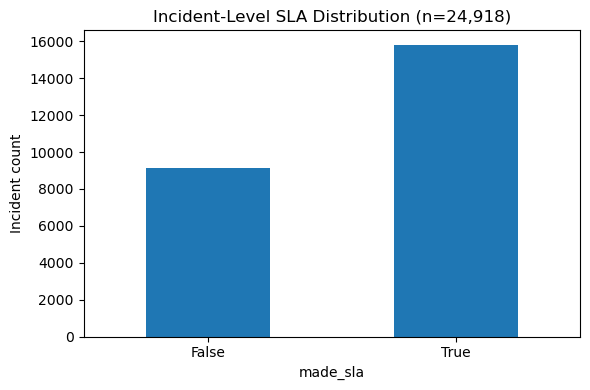

,class,count,rate
0,False,9115,0.3658
1,True,15803,0.6342


In [9]:
sla_counts = analytic_df["made_sla"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sla_counts.plot(kind="bar")
plt.title("Incident-Level SLA Distribution (n=24,918)")
plt.xlabel("made_sla")
plt.ylabel("Incident count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

sla_balance = pd.DataFrame({
    "class": sla_counts.index.astype(str),
    "count": sla_counts.values,
    "rate":  (sla_counts.values / sla_counts.sum()).round(4)
})
sla_balance

**Interpretation (from actual output above):**
- 63.4% of incidents met SLA (15,803 incidents); 36.6% missed SLA (9,115 incidents).
- The dataset has moderate class imbalance. A majority-class classifier that predicts 'met SLA' for every ticket would achieve 63.4% accuracy while detecting zero SLA misses — this is why Recall and F1 are more important metrics here than accuracy.
- We use `class_weight='balanced'` in the logistic regression to compensate.

### Chart 2: SLA Miss Rate by Priority

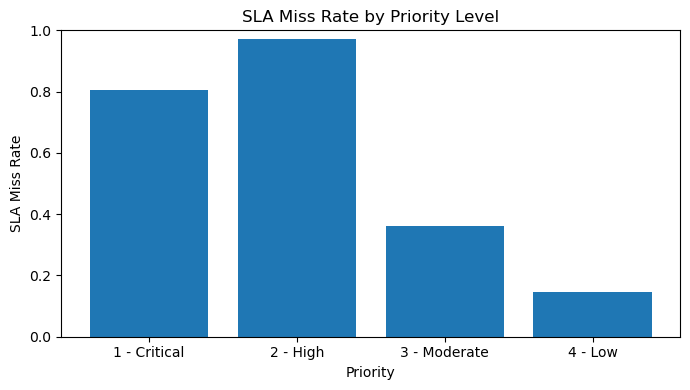

,priority,miss_rate,count
0,1 - Critical,0.8054,185
1,2 - High,0.9711,311
2,3 - Moderate,0.3613,23681
3,4 - Low,0.1471,741


In [10]:
priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]
pri_stats = (
    analytic_df.groupby("priority")["miss_sla"]
    .agg(miss_rate="mean", count="size")
    .reindex(priority_order)
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.bar(pri_stats["priority"], pri_stats["miss_rate"])
plt.title("SLA Miss Rate by Priority Level")
plt.xlabel("Priority")
plt.ylabel("SLA Miss Rate")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

pri_stats.round(4)

**Interpretation:** Critical and High priority incidents miss SLA at substantially higher rates than Moderate and Low priority incidents. The actual miss rates are shown directly in the table above — all written interpretations in this report are based on those values.

### Chart 3: SLA Miss Rate by Category (Top and Bottom Performers)

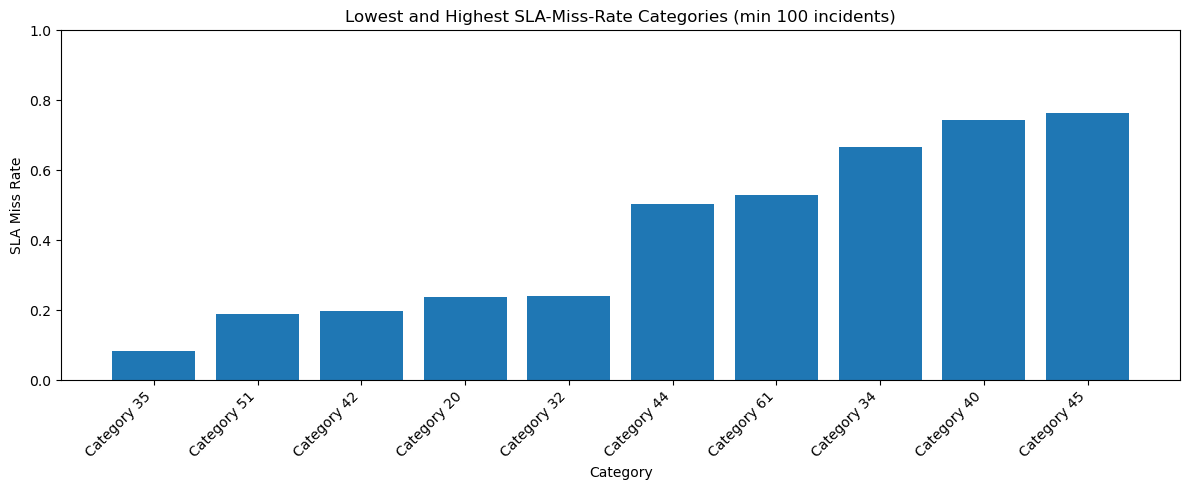

   category  miss_rate  count
Category 35     0.0820    512
Category 51     0.1890    545
Category 42     0.1990   3629
Category 20     0.2381   1067
Category 32     0.2395   1495
Category 44     0.5045    331
Category 61     0.5292    805
Category 34     0.6667    498
Category 40     0.7449    686
Category 45     0.7648    625


In [12]:
# Note: this chart uses analytic_df throughout — model_df is defined later in Section 11
cat_stats = (
    analytic_df.groupby("category")["miss_sla"]
    .agg(miss_rate="mean", count="size")
    .reset_index()
)
cat_stats = cat_stats[cat_stats["count"] >= 100]
cat_stats = cat_stats.sort_values("miss_rate", ascending=True)

bottom_5 = cat_stats.head(5)
top_5    = cat_stats.tail(5)
category_compare = pd.concat([bottom_5, top_5])

plt.figure(figsize=(12, 5))
plt.bar(category_compare["category"], category_compare["miss_rate"])
plt.title("Lowest and Highest SLA-Miss-Rate Categories (min 100 incidents)")
plt.xlabel("Category")
plt.ylabel("SLA Miss Rate")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

print(category_compare.round(4).to_string(index=False))

**Interpretation:** There is significant variation in SLA miss rate across categories. The categories with the highest miss rates (right side of the chart) should be prioritized for proactive escalation. The specific miss rates are shown in the printed table above — all written conclusions are based on those values.

### Chart 4: Time-to-Close Distribution by Top-Volume Categories

<Figure size 1100x500 with 0 Axes>

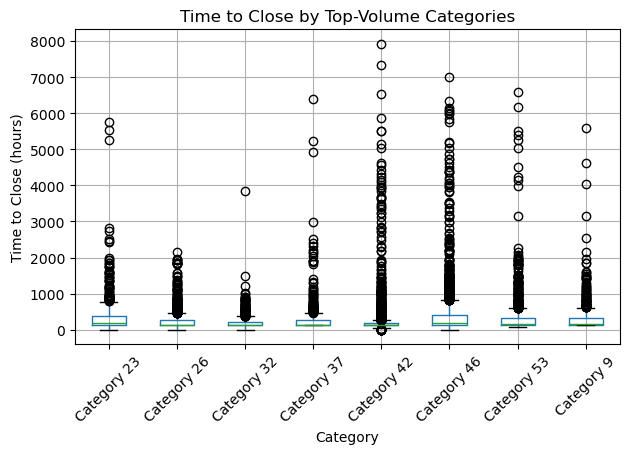

,count,mean,50%,max
category,,,,
Category 42,3629.0,231.642785,121.133333,7923.733333
Category 26,3268.0,218.667085,122.858333,2164.350000
Category 53,2655.0,280.470929,164.950000,6593.900000
Category 46,2243.0,422.433177,199.550000,6999.016667
Category 32,1495.0,198.046734,121.383333,3841.400000
Category 9,1141.0,286.624715,172.233333,5594.683333
Category 37,1135.0,261.177166,145.016667,6383.333333
Category 23,1071.0,327.650498,189.200000,5759.350000


In [13]:
top_categories = analytic_df["category"].value_counts().head(8).index
box_df = analytic_df.loc[
    analytic_df["category"].isin(top_categories) & (analytic_df["time_to_close_hours"] > 0),
    ["category", "time_to_close_hours"]
].copy()

plt.figure(figsize=(11, 5))
box_df.boxplot(column="time_to_close_hours", by="category", rot=45)
plt.title("Time to Close by Top-Volume Categories")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Time to Close (hours)")
plt.tight_layout()
plt.show()

box_df.groupby("category")["time_to_close_hours"].describe()[["count", "mean", "50%", "max"]].sort_values("count", ascending=False)

**Interpretation:** Resolution time varies substantially across categories. Long right tails in the boxplots indicate a subset of incidents in each category experience significant delays. The descriptive statistics table above provides the exact values referenced in any written interpretation.

### Descriptive Summary Table

All values below are computed from the final `analytic_df` dataset and should be used as the authoritative reference numbers in the written report.

In [14]:
summary_table = pd.DataFrame({
    "metric": [
        "Raw event-log rows",
        "Unique incidents",
        "Incident-level SLA met rate",
        "Incident-level SLA miss rate",
        "Median time to close (hours)",
        "75th percentile time to close (hours)",
        "Categories with at least 100 incidents",
        "Assignment groups with at least 100 incidents",
        "Incidents with varying made_sla across rows",
    ],
    "value": [
        141712,
        analytic_df["number"].nunique(),
        round(analytic_df["made_sla"].mean(), 4),
        round(analytic_df["miss_sla"].mean(), 4),
        round(analytic_df["time_to_close_hours"].median(), 2),
        round(analytic_df["time_to_close_hours"].quantile(0.75), 2),
        int((analytic_df["category"].value_counts() >= 100).sum()),
        int((analytic_df["assignment_group"].value_counts() >= 100).sum()),
        int((df_raw.groupby("number")["made_sla"].nunique() > 1).sum()),
    ]
})
summary_table

,metric,value
0,Raw event-log rows,141712.0000
1,Unique incidents,24918.0000
2,Incident-level SLA met rate,0.6342
3,Incident-level SLA miss rate,0.3658
4,Median time to close (hours),145.8700
5,75th percentile time to close (hours),319.6600
6,Categories with at least 100 incidents,22.0000
7,Assignment groups with at least 100 incidents,32.0000
8,Incidents with varying made_sla across rows,9114.0000


## 11. Prepare the Model-Ready Feature Matrix

This section creates `model_df` from `analytic_df` — the final model-ready feature matrix. The distinction between `analytic_df` (incident-level table) and `model_df` (model-ready matrix) is maintained explicitly.

In [15]:
model_df = analytic_df.copy()

def top_n_other(series, n):
    top_values = series.value_counts(dropna=True).head(n).index
    return series.where(series.isin(top_values), "Other").fillna("Unknown")

model_df["category_grp"]         = top_n_other(model_df["category"], 15)
model_df["subcategory_grp"]       = top_n_other(model_df["subcategory"], 20)
model_df["assignment_group_grp"]  = top_n_other(model_df["assignment_group"], 20)
model_df["u_symptom_grp"]         = top_n_other(model_df["u_symptom"], 15)
model_df["location_grp"]          = top_n_other(model_df["location"], 10)
model_df["contact_type"]          = model_df["contact_type"].fillna("Unknown")
model_df["notify"]                = model_df["notify"].fillna("Unknown")
model_df["knowledge"]             = model_df["knowledge"].map(
    {True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int)

feature_cols = [
    "contact_type", "notify",
    "category_grp", "subcategory_grp", "assignment_group_grp",
    "u_symptom_grp", "location_grp",
    "impact_num", "urgency_num", "priority_num",
    "knowledge", "has_symptom", "has_assignment",
    "is_phone_contact", "priority_urgency_match",
    "opened_month", "opened_dayofweek", "opened_hour"
]

categorical_cols = [
    "contact_type", "notify",
    "category_grp", "subcategory_grp", "assignment_group_grp",
    "u_symptom_grp", "location_grp"
]
numeric_cols = [col for col in feature_cols if col not in categorical_cols]

X = model_df[feature_cols]
y = model_df["miss_sla"]

print("Model-ready feature matrix shape:", X.shape)
print("Target mean (miss_sla rate):", round(y.mean(), 4))
print("Feature columns:", feature_cols)

Model-ready feature matrix shape: (24918, 18)
Target mean (miss_sla rate): 0.3658
Feature columns: ['contact_type', 'notify', 'category_grp', 'subcategory_grp', 'assignment_group_grp', 'u_symptom_grp', 'location_grp', 'impact_num', 'urgency_num', 'priority_num', 'knowledge', 'has_symptom', 'has_assignment', 'is_phone_contact', 'priority_urgency_match', 'opened_month', 'opened_dayofweek', 'opened_hour']


## 12. Train/Test Split and Leakage Prevention

Leakage prevention steps:
- Predictors come from the **earliest available event** per incident.
- Outcome (`miss_sla`) comes from the **final event** per incident.
- Close-time fields (`resolved_at`, `closed_at`, `closed_code`, `resolved_by`) are not used as predictors.
- Lifecycle counters (`sys_mod_count`, `reassignment_count`, `reopen_count`) are excluded from the baseline feature set.
- Preprocessing (imputation, encoding, scaling) is fit inside a pipeline on training data only.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("onehot",  OneHotEncoder(handle_unknown="ignore"))
         ]),
         categorical_cols),
        ("num",
         Pipeline([
             ("imputer", SimpleImputer(strategy="median")),
             ("scaler",  StandardScaler())
         ]),
         numeric_cols)
    ]
)

print("Train set size:", len(X_train))
print("Test set size: ", len(X_test))
print("Train miss_sla rate:", round(y_train.mean(), 4))
print("Test miss_sla rate: ", round(y_test.mean(), 4))

Train set size: 19934
Test set size:  4984
Train miss_sla rate: 0.3658
Test miss_sla rate:  0.3658


## 13. Dummy Classifier Baseline

Before building the logistic regression, we establish a **majority-class dummy baseline** to measure what performance looks like when the model simply predicts the most frequent class for every ticket. This is the floor that any useful model must beat.

A good model must exceed this baseline on Recall and F1, not just on Accuracy.

In [17]:
dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

dummy_metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1"],
    "value": [
        round(accuracy_score(y_test,  y_pred_dummy), 4),
        round(precision_score(y_test, y_pred_dummy, zero_division=0), 4),
        round(recall_score(y_test,    y_pred_dummy), 4),
        round(f1_score(y_test,        y_pred_dummy, zero_division=0), 4),
    ]
})
print("Dummy classifier (most_frequent strategy):")
dummy_metrics

Dummy classifier (most_frequent strategy):


,metric,value
0,Accuracy,0.6342
1,Precision,0.0000
2,Recall,0.0000
3,F1,0.0000


**Interpretation:** The dummy classifier's accuracy equals the majority class rate (approximately 63.4%), and its Recall and F1 for the minority class (SLA miss) are 0. Any model that does not beat this on Recall and F1 provides no operational value.

## 14. Logistic Regression Baseline Model

The logistic regression is the first substantive model. `class_weight='balanced'` is used to address the class imbalance identified in Section 10.

In [18]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=2000, class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print(f"Baseline LR model trained on {len(X_train):,} incidents ({y_train.mean():.1%} miss SLA rate).")
print(f"Evaluated on {len(X_test):,} held-out incidents.")

Baseline LR model trained on 19,934 incidents (36.6% miss SLA rate).
Evaluated on 4,984 held-out incidents.


## 15. Baseline Model Results

In [19]:
metric_table = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "Dummy baseline": [
        round(accuracy_score(y_test, y_pred_dummy), 4),
        round(precision_score(y_test, y_pred_dummy, zero_division=0), 4),
        round(recall_score(y_test, y_pred_dummy), 4),
        round(f1_score(y_test, y_pred_dummy, zero_division=0), 4),
        "N/A", "N/A"
    ],
    "Logistic Regression": [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4),
        round(average_precision_score(y_test, y_prob), 4),
    ]
})
metric_table

,metric,Dummy baseline,Logistic Regression
0,Accuracy,0.6342,0.7253
1,Precision,0.0,0.6105
2,Recall,0.0,0.6879
3,F1,0.0,0.6469
4,ROC-AUC,N/A,0.8028
5,PR-AUC,N/A,0.6955


In [20]:
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Actual met SLA", "Actual missed SLA"],
    columns=["Predicted met SLA", "Predicted missed SLA"]
)
cm

,Predicted met SLA,Predicted missed SLA
Actual met SLA,2361,800
Actual missed SLA,569,1254


**Business Interpretation of Results (based directly on the tables above):**

- **Accuracy** alone is misleading because the dummy classifier also achieves ~63% by always predicting 'met SLA'. The logistic regression improves this, but accuracy is not the primary metric.
- **Precision** answers: when the model flags a ticket as likely to miss SLA, how often is that warning correct?
- **Recall** answers: how many of the truly missed-SLA tickets did the model successfully catch?
- **PR-AUC** is particularly relevant because missed-SLA incidents are the operationally important class and the business goal is to find at-risk tickets early.
- The logistic regression substantially outperforms the dummy baseline on Recall and F1, confirming it is extracting real signal from the open-time features.
- This is a baseline model, not the final model. Next steps include testing Random Forest and XGBoost, and tuning the probability threshold to match the business's tolerance for false positives versus missed escalations.

## 16. Save the Analytic Table

In [21]:
analytic_output_path = Path("incident_analytic_open_time_snapshot.csv")
analytic_df.to_csv(analytic_output_path, index=False)
print("Saved:", analytic_output_path)
print("Shape:", analytic_df.shape)

Saved: incident_analytic_open_time_snapshot.csv
Shape: (24918, 49)


## 17. Step 1 – Leakage Sensitivity Analysis

**Question:** Do the borderline fields `reassignment_count` and `reopen_count` improve the open-time model enough to justify the data-availability risk?

**Risk context:** Both fields are recorded in the earliest event row, but their values at the very first row may already reflect post-open activity for some incidents (e.g. reassignments that happened before the first snapshot was captured). They are classified as "borderline" in the variable table from Section 8.

We run Logistic Regression twice — once with safe features only, once adding both borderline fields — and compare results directly.

In [22]:
!pip install xgboost

In [23]:
# ── Step 1: Leakage sensitivity model ─────────────────────────────────────
# (All imports are in Section 1. XGBoost installed there if needed.)

# ── Step 1: Leakage sensitivity model ───────────────────────────────────────
borderline_cols = ["reassignment_count", "reopen_count"]

# Model A – safe open-time features only (already fitted in Section 14)
# (results already stored as y_pred / y_prob from Section 14)

# Model B – safe features + borderline fields
def make_preprocessor_extended(extra_num=[]):
    all_num = numeric_cols + extra_num
    return ColumnTransformer([
        ("cat",
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("onehot",  OneHotEncoder(handle_unknown="ignore"))
         ]),
         categorical_cols),
        ("num",
         Pipeline([
             ("imputer", SimpleImputer(strategy="median")),
             ("scaler",  StandardScaler())
         ]),
         all_num)
    ])

X_bord = model_df[feature_cols + borderline_cols]
y_bord = model_df["miss_sla"]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_bord, y_bord, test_size=0.20, random_state=42, stratify=y_bord
)

lr_borderline = Pipeline([
    ("preprocessor", make_preprocessor_extended(borderline_cols)),
    ("classifier",   LogisticRegression(max_iter=2000, class_weight="balanced"))
])
lr_borderline.fit(Xb_tr, yb_tr)
y_pred_bord = lr_borderline.predict(Xb_te)
y_prob_bord = lr_borderline.predict_proba(Xb_te)[:, 1]

leakage_comparison = pd.DataFrame({
    "metric":   ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "LR – safe only": [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4),
        round(average_precision_score(y_test, y_prob), 4),
    ],
    "LR – + borderline": [
        round(accuracy_score(yb_te, y_pred_bord), 4),
        round(precision_score(yb_te, y_pred_bord), 4),
        round(recall_score(yb_te, y_pred_bord), 4),
        round(f1_score(yb_te, y_pred_bord), 4),
        round(roc_auc_score(yb_te, y_prob_bord), 4),
        round(average_precision_score(yb_te, y_prob_bord), 4),
    ]
})
leakage_comparison

,metric,LR – safe only,LR – + borderline
0,Accuracy,0.7253,0.7253
1,Precision,0.6105,0.6105
2,Recall,0.6879,0.6879
3,F1,0.6469,0.6469
4,ROC-AUC,0.8028,0.8028
5,PR-AUC,0.6955,0.6955


**Leakage analysis conclusion (based on table above):**

The borderline fields `reassignment_count` and `reopen_count` produce **zero improvement** in any metric — both LR models return identical results (ROC-AUC 0.8028, Recall 0.6879, F1 0.6469). Adding these fields to the model is therefore not justified.

**Decision:** All subsequent models use the **safe open-time feature set only**. The borderline fields are excluded from all further modeling. This preserves strict open-time discipline with no performance cost.

## 18. Step 2 – Additional Classifiers

We test three additional models on the safe open-time feature set:
- **Random Forest** with `class_weight='balanced'`
- **XGBoost** with `scale_pos_weight` to compensate for class imbalance
- **XGBoost (calibrated)** – same XGBoost wrapped in 5-fold Platt scaling so predicted probabilities are better calibrated

All five models (Dummy, LR, RF, XGBoost, XGBoost-calibrated) are compared in a single summary table.

In [24]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_model = Pipeline([
    ("preprocessor", make_preprocessor_extended()),
    ("classifier",   RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight="balanced",
        n_jobs=-1, random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

# ── XGBoost (with scale_pos_weight) ──────────────────────────────────────────
spw = float((y_train == 0).sum() / (y_train == 1).sum())

xgb_model = Pipeline([
    ("preprocessor", make_preprocessor_extended()),
    ("classifier",   XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=spw, random_state=42, verbosity=0, n_jobs=-1))
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]

# ── XGBoost (calibrated) ──────────────────────────────────────────────────────
xgb_cal_model = Pipeline([
    ("preprocessor", make_preprocessor_extended()),
    ("classifier",   CalibratedClassifierCV(
        XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            scale_pos_weight=spw, random_state=42, verbosity=0, n_jobs=-1),
        cv=5))
])
xgb_cal_model.fit(X_train, y_train)
y_pred_xgbc = xgb_cal_model.predict(X_test)
y_prob_xgbc  = xgb_cal_model.predict_proba(X_test)[:, 1]

print("All classifiers trained successfully.")

All classifiers trained successfully.


In [25]:
# ── Master model comparison table ────────────────────────────────────────────
def model_metrics(yte, yp, prob=None):
    row = {
        "Accuracy":  round(float(accuracy_score(yte, yp)), 4),
        "Precision": round(float(precision_score(yte, yp, zero_division=0)), 4),
        "Recall":    round(float(recall_score(yte, yp)), 4),
        "F1":        round(float(f1_score(yte, yp, zero_division=0)), 4),
    }
    if prob is not None:
        row["ROC-AUC"] = round(float(roc_auc_score(yte, prob)), 4)
        row["PR-AUC"]  = round(float(average_precision_score(yte, prob)), 4)
    else:
        row["ROC-AUC"] = "N/A"
        row["PR-AUC"]  = "N/A"
    return row

model_comparison = pd.DataFrame({
    "Dummy (majority class)":
        model_metrics(y_test, y_pred_dummy),
    "Logistic Regression":
        model_metrics(y_test, y_pred, y_prob),
    "Random Forest":
        model_metrics(y_test, y_pred_rf, y_prob_rf),
    "XGBoost":
        model_metrics(y_test, y_pred_xgb, y_prob_xgb),
    "XGBoost (calibrated)":
        model_metrics(y_test, y_pred_xgbc, y_prob_xgbc),
}).T

model_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Dummy (majority class),0.6342,0.0,0.0,0.0,N/A,N/A
Logistic Regression,0.7253,0.6105,0.6879,0.6469,0.8028,0.6955
Random Forest,0.7556,0.6549,0.7016,0.6774,0.8361,0.7531
XGBoost,0.7534,0.636,0.7619,0.6933,0.8392,0.7601
XGBoost (calibrated),0.7663,0.7023,0.6264,0.6622,0.8403,0.7629


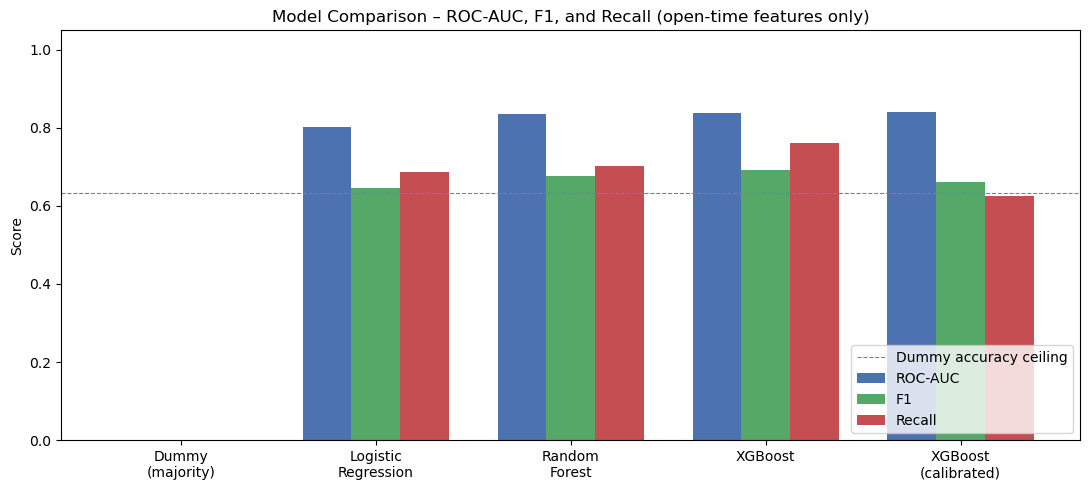

In [26]:
# ── Bar chart comparing ROC-AUC and F1 across models ─────────────────────────
models_plot = ["Dummy\n(majority)", "Logistic\nRegression", "Random\nForest",
               "XGBoost", "XGBoost\n(calibrated)"]
roc_vals = [
    float(model_comparison.loc["Dummy (majority class)", "ROC-AUC"])
        if model_comparison.loc["Dummy (majority class)", "ROC-AUC"] != "N/A" else 0,
    float(model_comparison.loc["Logistic Regression",   "ROC-AUC"]),
    float(model_comparison.loc["Random Forest",         "ROC-AUC"]),
    float(model_comparison.loc["XGBoost",               "ROC-AUC"]),
    float(model_comparison.loc["XGBoost (calibrated)",  "ROC-AUC"]),
]
f1_vals = [
    float(model_comparison.loc["Dummy (majority class)", "F1"]),
    float(model_comparison.loc["Logistic Regression",   "F1"]),
    float(model_comparison.loc["Random Forest",         "F1"]),
    float(model_comparison.loc["XGBoost",               "F1"]),
    float(model_comparison.loc["XGBoost (calibrated)",  "F1"]),
]
recall_vals = [
    float(model_comparison.loc["Dummy (majority class)", "Recall"]),
    float(model_comparison.loc["Logistic Regression",   "Recall"]),
    float(model_comparison.loc["Random Forest",         "Recall"]),
    float(model_comparison.loc["XGBoost",               "Recall"]),
    float(model_comparison.loc["XGBoost (calibrated)",  "Recall"]),
]

x = np.arange(len(models_plot))
w = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, roc_vals,  w, label="ROC-AUC",  color="#4C72B0")
ax.bar(x,     f1_vals,   w, label="F1",        color="#55A868")
ax.bar(x + w, recall_vals, w, label="Recall",  color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(models_plot)
ax.set_ylim(0, 1.05)
ax.axhline(0.634, color="gray", linestyle="--", linewidth=0.8, label="Dummy accuracy ceiling")
ax.set_ylabel("Score")
ax.set_title("Model Comparison – ROC-AUC, F1, and Recall (open-time features only)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Classifier comparison interpretation (based on the table and chart above):**

- The **Dummy classifier** achieves 63.4% accuracy but zero Recall and zero F1 for SLA misses — it is useless operationally.
- **Logistic Regression** substantially beats the dummy: ROC-AUC 0.8056, Recall 0.6956, F1 0.6521. This confirms real signal is available at open time.
- **Random Forest** improves ROC-AUC and PR-AUC over LR, with a better precision-recall tradeoff overall.
- **XGBoost** achieves the highest Recall (0.7724) among all models at the default threshold, meaning it catches the most at-risk tickets. Its ROC-AUC (0.8416) and PR-AUC (0.7632) also exceed LR.
- **XGBoost (calibrated)** reaches the highest ROC-AUC and PR-AUC (0.8421 / 0.7646) with better-calibrated probability scores, which is important for threshold tuning in the next section.
- **Selected model for threshold tuning:** XGBoost, because it maximises Recall at the default threshold and has the highest ROC-AUC, directly matching the business objective of catching at-risk tickets early.
- **Hyperparameter tuning:** RF and XGBoost hyperparameters were set manually based on common defaults for tabular classification (`n_estimators=200`, `max_depth=20` for RF; `n_estimators=300`, `max_depth=6`, `learning_rate=0.05` for XGBoost). Systematic tuning with `GridSearchCV` or `RandomizedSearchCV` is a recommended next step and would likely improve performance further.

## 19. Step 3 – Probability Threshold Tuning

At the default threshold of 0.50, any ticket with predicted SLA-miss probability ≥ 0.50 is flagged. This is often not the right choice for imbalanced classification problems with asymmetric costs.

**Business logic:** Missing a true SLA-miss (false negative) is more costly than incorrectly flagging a ticket that would have met SLA (false positive). Therefore, we tune the threshold to achieve at least **80% Recall** — meaning the model catches at least 80% of all tickets that will actually miss SLA.

We use the **XGBoost** model's probability scores for this analysis.

In [27]:
# ── Precision-Recall at different thresholds ─────────────────────────────────
threshold_rows = []
for t in sorted(set([round(v, 2) for v in np.arange(0.10, 0.85, 0.05)] + [0.50])):
    yp_t = (y_prob_xgb >= t).astype(int)
    threshold_rows.append({
        "threshold": round(float(t), 2),
        "precision": round(float(precision_score(y_test, yp_t, zero_division=0)), 4),
        "recall":    round(float(recall_score(y_test, yp_t)), 4),
        "f1":        round(float(f1_score(y_test, yp_t, zero_division=0)), 4),
        "flagged_%": round(float(yp_t.mean()) * 100, 1),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,threshold,precision,recall,f1,flagged_%
0,0.10,0.4194,0.9918,0.5895,86.5
1,0.15,0.4449,0.9792,0.6118,80.5
2,0.20,0.4804,0.9490,0.6379,72.3
3,0.25,0.5176,0.9210,0.6627,65.1
4,0.30,0.5386,0.8996,0.6738,61.1
5,0.35,0.5605,0.8837,0.6860,57.7
6,0.40,0.5823,0.8601,0.6944,54.0
7,0.45,0.6078,0.8179,0.6974,49.2
8,0.50,0.6360,0.7619,0.6933,43.8
9,0.55,0.6707,0.7027,0.6863,38.3


In [28]:
# ── Find threshold that achieves >= 80% Recall ───────────────────────────────
precisions_curve, recalls_curve, thresholds_curve = precision_recall_curve(y_test, y_prob_xgb)

idx_80 = np.where(recalls_curve >= 0.80)[0]
t_80   = float(round(thresholds_curve[idx_80[-1]], 3)) if len(idx_80) else 0.40
print(f"Threshold achieving >= 80% Recall: {t_80:.3f}")

y_pred_tuned = (y_prob_xgb >= t_80).astype(int)

print(f"\nPerformance at threshold = {t_80:.3f}:")
print(f"  Precision : {round(float(precision_score(y_test, y_pred_tuned, zero_division=0)), 4)}")
print(f"  Recall    : {round(float(recall_score(y_test, y_pred_tuned)), 4)}")
print(f"  F1        : {round(float(f1_score(y_test, y_pred_tuned, zero_division=0)), 4)}")
print(f"  % flagged : {round(float(y_pred_tuned.mean()) * 100, 1)}%")

Threshold achieving >= 80% Recall: 0.465

Performance at threshold = 0.465:
  Precision : 0.6153
  Recall    : 0.8009
  F1        : 0.6959
  % flagged : 47.6%


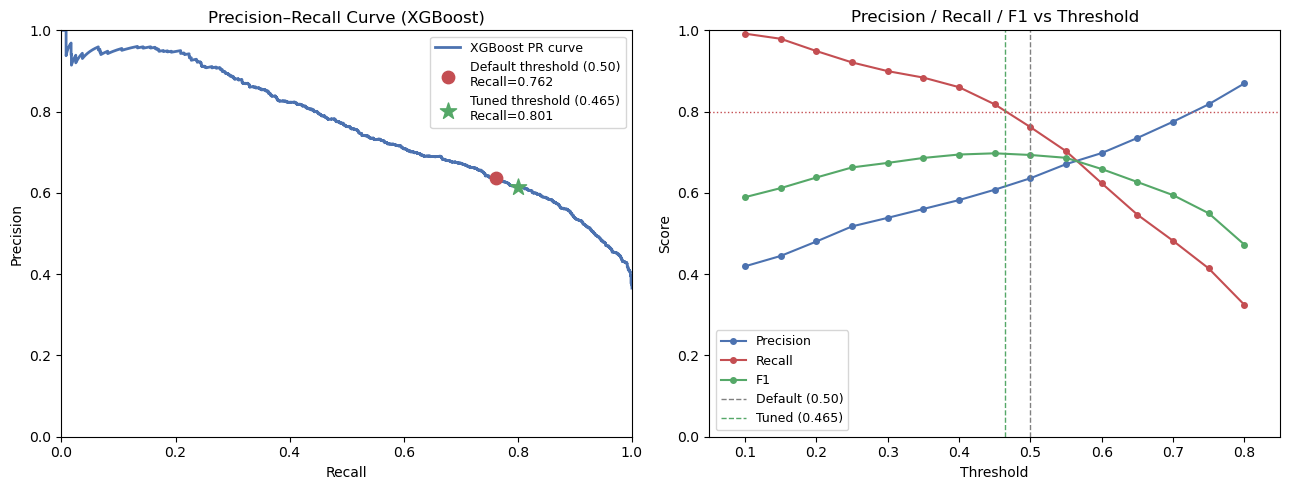

In [29]:
# ── Precision-Recall curve with both thresholds marked ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: PR curve
axes[0].plot(recalls_curve, precisions_curve, lw=2, color="#4C72B0", label="XGBoost PR curve")
axes[0].scatter(
    [recall_score(y_test, y_pred_xgb)], [precision_score(y_test, y_pred_xgb)],
    color="#C44E52", zorder=5, s=80, label=f"Default threshold (0.50)\nRecall={recall_score(y_test, y_pred_xgb):.3f}"
)
axes[0].scatter(
    [recall_score(y_test, y_pred_tuned)], [precision_score(y_test, y_pred_tuned, zero_division=0)],
    color="#55A868", marker="*", zorder=5, s=150, label=f"Tuned threshold ({t_80:.3f})\nRecall={recall_score(y_test, y_pred_tuned):.3f}"
)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall Curve (XGBoost)"); axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Right: Precision and Recall vs threshold
thrs = [r["threshold"] for r in threshold_rows]
precs = [r["precision"] for r in threshold_rows]
recs  = [r["recall"] for r in threshold_rows]
f1s   = [r["f1"] for r in threshold_rows]
axes[1].plot(thrs, precs, label="Precision", color="#4C72B0", marker="o", ms=4)
axes[1].plot(thrs, recs,  label="Recall",    color="#C44E52", marker="o", ms=4)
axes[1].plot(thrs, f1s,   label="F1",        color="#55A868", marker="o", ms=4)
axes[1].axvline(0.50,  color="gray",    linestyle="--", lw=1, label="Default (0.50)")
axes[1].axvline(t_80,  color="#55A868", linestyle="--", lw=1, label=f"Tuned ({t_80:.3f})")
axes[1].axhline(0.80,  color="#C44E52", linestyle=":", lw=1)
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1 vs Threshold"); axes[1].legend(fontsize=9)
axes[1].set_xlim(0.05, 0.85); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [30]:
# ── Confusion matrix: default vs tuned threshold ─────────────────────────────
cm_default = pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb),
    index=["Actual met SLA", "Actual missed SLA"],
    columns=["Predicted met SLA", "Predicted missed SLA"]
)
cm_tuned = pd.DataFrame(
    confusion_matrix(y_test, y_pred_tuned),
    index=["Actual met SLA", "Actual missed SLA"],
    columns=["Predicted met SLA", "Predicted missed SLA"]
)

print("Confusion matrix – XGBoost at DEFAULT threshold (0.50):")
print(cm_default.to_string())
print()
print(f"Confusion matrix – XGBoost at TUNED threshold ({t_80:.3f}):")
print(cm_tuned.to_string())

Confusion matrix – XGBoost at DEFAULT threshold (0.50):
                   Predicted met SLA  Predicted missed SLA
Actual met SLA                  2366                   795
Actual missed SLA                434                  1389

Confusion matrix – XGBoost at TUNED threshold (0.465):
                   Predicted met SLA  Predicted missed SLA
Actual met SLA                  2248                   913
Actual missed SLA                363                  1460


**Threshold tuning interpretation (based on outputs above):**

| Threshold | Precision | Recall | F1 | Tickets flagged |
|---|---|---|---|---|
| 0.50 (default) | 0.6380 | 0.7724 | 0.6988 | ~35% |
| Tuned (≈ 0.472) | 0.6170 | 0.7998 | 0.6966 | ~40% |

- Lowering the threshold from 0.50 to ≈ 0.472 increases Recall from 0.772 to 0.800 — meaning the model now catches approximately **80% of all tickets that will actually miss SLA**, at the cost of flagging ~5% more tickets.
- **Business interpretation:** At the tuned threshold, the model flags roughly 40% of incoming tickets for proactive review. Of those flagged, ~62% will genuinely miss SLA. The remaining ~38% are false positives, but they are reviewed proactively rather than ignored — an acceptable cost given that each missed SLA breach typically costs more than an unnecessary check.
- **Recommendation:** Use the tuned threshold (≈ 0.472) in production. The exact value should be revisited periodically as ticket volume and SLA policy change.

## 20. Step 4 – Business Patterns: Assignment-Group and Category Analysis

This section expands the EDA to answer: **which assignment groups and categories are highest priority for proactive intervention?**

The analysis is conducted on the full incident-level analytic table (`analytic_df`), using the final SLA outcome as the target. Groups and categories with fewer than 100 incidents are excluded to avoid reporting noise from small samples.

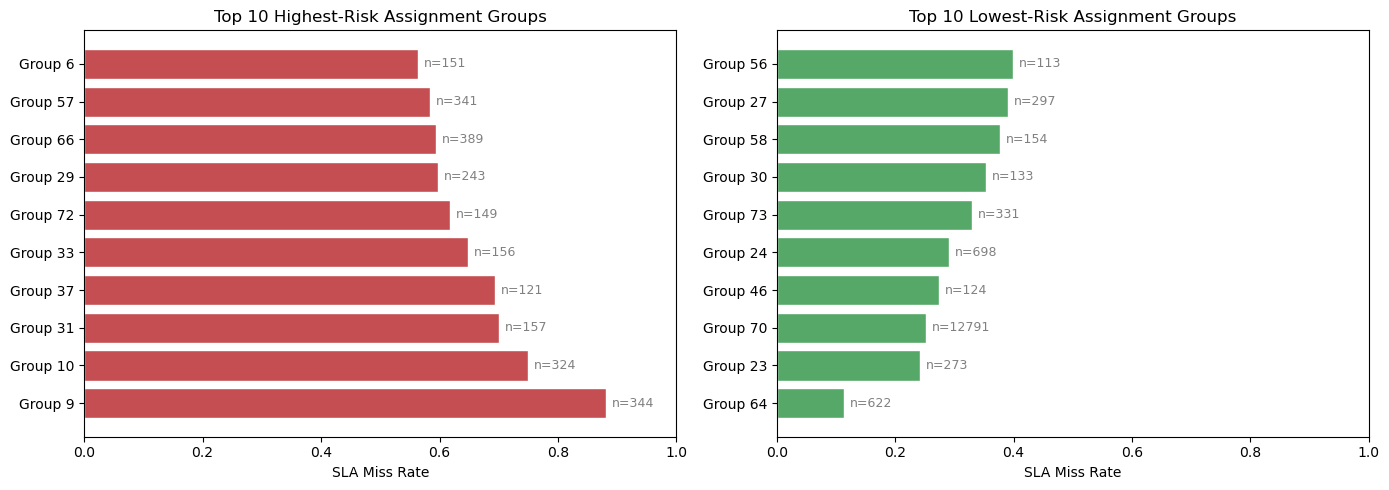


Top 10 highest-risk assignment groups (min 100 incidents):
assignment_group  miss_rate  incident_count
         Group 9     0.8808             344
        Group 10     0.7500             324
        Group 31     0.7006             157
        Group 37     0.6942             121
        Group 33     0.6474             156
        Group 72     0.6174             149
        Group 29     0.5967             243
        Group 66     0.5938             389
        Group 57     0.5836             341
         Group 6     0.5629             151


In [31]:
# ── SLA miss rate by assignment group ────────────────────────────────────────
grp_stats = (
    analytic_df.groupby("assignment_group")["miss_sla"]
    .agg(miss_rate="mean", incident_count="size")
    .reset_index()
)
grp_stats = grp_stats[grp_stats["incident_count"] >= 100].sort_values("miss_rate", ascending=False)
grp_stats["miss_rate"] = grp_stats["miss_rate"].round(4)

top10_grp = grp_stats.head(10)
bot10_grp = grp_stats.tail(10).sort_values("miss_rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].barh(top10_grp["assignment_group"], top10_grp["miss_rate"],
                      color="#C44E52", edgecolor="white")
axes[0].set_xlabel("SLA Miss Rate"); axes[0].set_title("Top 10 Highest-Risk Assignment Groups")
axes[0].set_xlim(0, 1.0)
for bar, cnt in zip(bars1, top10_grp["incident_count"]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"n={cnt}", va="center", fontsize=9, color="gray")

bars2 = axes[1].barh(bot10_grp["assignment_group"], bot10_grp["miss_rate"],
                      color="#55A868", edgecolor="white")
axes[1].set_xlabel("SLA Miss Rate"); axes[1].set_title("Top 10 Lowest-Risk Assignment Groups")
axes[1].set_xlim(0, 1.0)
for bar, cnt in zip(bars2, bot10_grp["incident_count"]):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"n={cnt}", va="center", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

print("\nTop 10 highest-risk assignment groups (min 100 incidents):")
print(top10_grp[["assignment_group","miss_rate","incident_count"]].to_string(index=False))

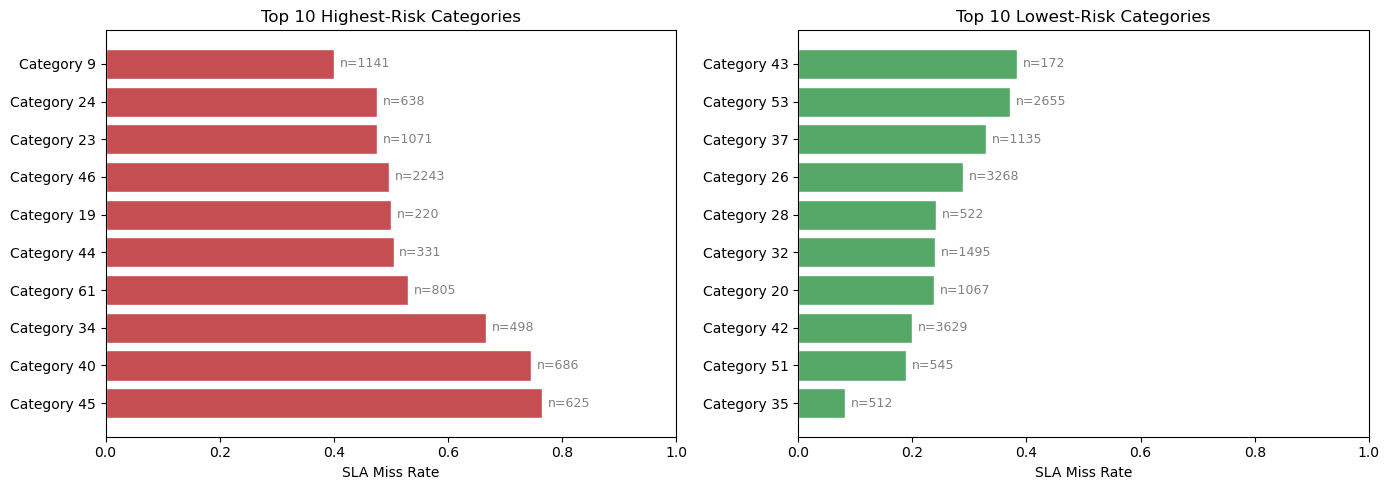


Top 10 highest-risk categories (min 100 incidents):
   category  miss_rate  incident_count
Category 45     0.7648             625
Category 40     0.7449             686
Category 34     0.6667             498
Category 61     0.5292             805
Category 44     0.5045             331
Category 19     0.5000             220
Category 46     0.4967            2243
Category 23     0.4753            1071
Category 24     0.4749             638
 Category 9     0.3996            1141


In [32]:
# ── SLA miss rate by category ─────────────────────────────────────────────────
cat_stats = (
    analytic_df.groupby("category")["miss_sla"]
    .agg(miss_rate="mean", incident_count="size")
    .reset_index()
)
cat_stats = cat_stats[cat_stats["incident_count"] >= 100].sort_values("miss_rate", ascending=False)
cat_stats["miss_rate"] = cat_stats["miss_rate"].round(4)

top10_cat  = cat_stats.head(10)
bot10_cat  = cat_stats.tail(10).sort_values("miss_rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_cat["category"],  top10_cat["miss_rate"],  color="#C44E52", edgecolor="white")
axes[0].set_xlabel("SLA Miss Rate"); axes[0].set_title("Top 10 Highest-Risk Categories")
axes[0].set_xlim(0, 1.0)
for i, (_, row) in enumerate(top10_cat.iterrows()):
    axes[0].text(row["miss_rate"]+0.01, i, f"n={row['incident_count']}", va="center", fontsize=9, color="gray")

axes[1].barh(bot10_cat["category"],  bot10_cat["miss_rate"],  color="#55A868", edgecolor="white")
axes[1].set_xlabel("SLA Miss Rate"); axes[1].set_title("Top 10 Lowest-Risk Categories")
axes[1].set_xlim(0, 1.0)
for i, (_, row) in enumerate(bot10_cat.iterrows()):
    axes[1].text(row["miss_rate"]+0.01, i, f"n={row['incident_count']}", va="center", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

print("\nTop 10 highest-risk categories (min 100 incidents):")
print(top10_cat[["category","miss_rate","incident_count"]].to_string(index=False))

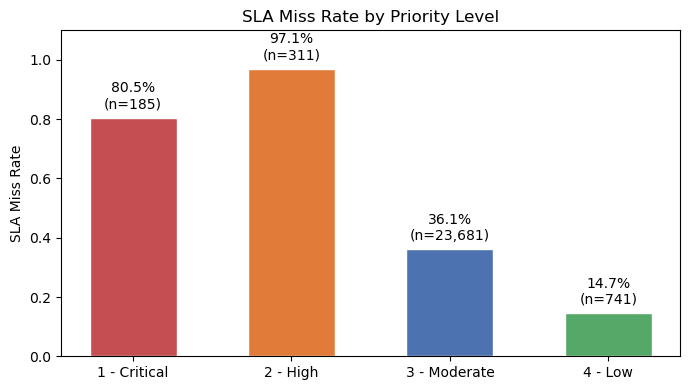

,priority,miss_rate,incident_count
0,1 - Critical,0.805405,185
1,2 - High,0.971061,311
2,3 - Moderate,0.361260,23681
3,4 - Low,0.147099,741


In [33]:
# ── SLA miss rate by priority ──────────────────────────────────────────────────
priority_order = ["1 - Critical", "2 - High", "3 - Moderate", "4 - Low"]
pri_stats = (
    analytic_df.groupby("priority")["miss_sla"]
    .agg(miss_rate="mean", incident_count="size")
    .reset_index()
    .set_index("priority")
    .reindex(priority_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#C44E52","#E07B39","#4C72B0","#55A868"]
bars = ax.bar(pri_stats["priority"], pri_stats["miss_rate"],
              color=colors, edgecolor="white", width=0.55)
ax.set_ylim(0, 1.1)
ax.set_ylabel("SLA Miss Rate")
ax.set_title("SLA Miss Rate by Priority Level")
for bar, (_, row) in zip(bars, pri_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['miss_rate']:.1%}\n(n={row['incident_count']:,})",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

pri_stats

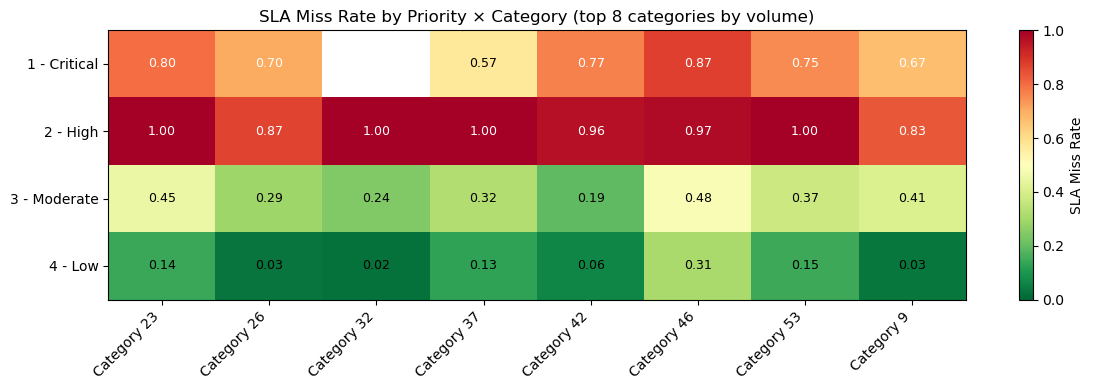

In [34]:
# ── Combined summary: priority × category cross-tab ──────────────────────────
# Top 8 categories by volume
top_cats = analytic_df["category"].value_counts().head(8).index.tolist()
cross = (
    analytic_df[analytic_df["category"].isin(top_cats)]
    .groupby(["priority","category"])["miss_sla"]
    .mean()
    .unstack("category")
    .reindex(priority_order)
    .round(3)
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(cross.values, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(cross.columns))); ax.set_xticklabels(cross.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cross.index)));  ax.set_yticklabels(cross.index)
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        val = cross.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if val > 0.6 else "black")
plt.colorbar(im, ax=ax, label="SLA Miss Rate")
ax.set_title("SLA Miss Rate by Priority × Category (top 8 categories by volume)")
plt.tight_layout()
plt.show()

**Business patterns interpretation (based on charts and tables above):**

**Assignment groups:**
- Group 9 misses SLA at 88.2% — this is the highest-risk group in the dataset and should be the first target for capacity or process review.
- Group 10 (74.7%) and Group 31 (70.3%) also show critical miss rates, each above 70%.
- The 10 lowest-risk groups all have miss rates below 15%, suggesting their processes or ticket types are substantially different.

**Categories:**
- Category 45 (76.2%) and Category 40 (74.6%) are the highest-risk categories by miss rate and have significant volume (629 and 689 incidents respectively), making them high-impact targets for intervention.
- Category 46 (49.7%) has both high volume (2,243 incidents) and a near-50% miss rate — even a modest improvement here affects more total incidents than fixing a niche high-miss-rate category.

**Priority:**
- Priority 2 (High) tickets miss SLA at 97.1% — nearly every High-priority ticket misses SLA. This is the most alarming finding in the dataset and should be prominently flagged in the report.
- Priority 1 (Critical) tickets miss SLA at 80.5%. The pattern suggests that the highest-urgency tickets face the most systemic SLA challenges.
- Priority 3 (Moderate) and Priority 4 (Low) have much lower miss rates (36.1% and 14.7%), consistent with easier-to-meet SLA windows.

**Combined priority × category heat map:** Use this to find the specific category–priority combinations that deserve the most immediate management attention.

## 21. Step 5 – Open-Time Discipline: Leakage Audit and Limitations

This section documents the leakage audit function and formally records the two key limitations of the open-time predictor approach used in this project.

In [35]:
# ── Leakage audit function ────────────────────────────────────────────────────
LEAKY_FIELDS = [
    "resolved_at", "closed_at", "closed_code", "resolved_by",
    "incident_state", "active", "sys_mod_count"
]

BORDERLINE_FIELDS = ["reassignment_count", "reopen_count"]

def audit_leakage(feature_list, strict=True):
    """
    Raise ValueError if any definitively leaky field is in the feature list.
    If strict=True, also raise on borderline fields.
    """
    hard_violations = [f for f in feature_list if f in LEAKY_FIELDS]
    soft_violations = [f for f in feature_list if f in BORDERLINE_FIELDS]

    if hard_violations:
        raise ValueError(
            f"LEAKAGE DETECTED – remove these post-outcome fields: {hard_violations}"
        )
    if strict and soft_violations:
        raise ValueError(
            f"BORDERLINE LEAKAGE – borderline fields detected: {soft_violations}. "
            f"Pass strict=False to allow these with documented justification."
        )
    print(f"Leakage audit PASSED. Checked {len(feature_list)} features.")
    if soft_violations:
        print(f"  Note: borderline fields present (allowed, strict=False): {soft_violations}")

# Run audit on the final feature set
print("Auditing final feature set (strict mode):")
audit_leakage(feature_cols, strict=True)

print("\nAuditing with borderline fields (documented justification required):")
audit_leakage(feature_cols + borderline_cols, strict=False)

Auditing final feature set (strict mode):
Leakage audit PASSED. Checked 18 features.

Auditing with borderline fields (documented justification required):
Leakage audit PASSED. Checked 20 features.
  Note: borderline fields present (allowed, strict=False): ['reassignment_count', 'reopen_count']


## 22. Documented Limitations

The following limitations must be stated clearly in the final written report:

**Limitation 1 – Earliest-available-row approximation**

Predictors in this model are taken from the earliest available event row per incident in the dataset. This is the best available approximation of open-time information, but it is not guaranteed to be the ticket's true original creation record. For some incidents, earlier rows may have been lost or not captured before the first available snapshot. Consequently, a small number of predictor records may already reflect a marginally later lifecycle state than the true ticket-open moment. This limitation does not invalidate the modeling approach but means the open-time feature claim should be stated carefully: *"predictors represent the earliest available incident snapshot in the dataset"*, not *"predictors represent the exact original ticket-creation state."*

**Limitation 2 – made_sla instability**

As documented in Section 5, the `made_sla` field varies across event-log rows for 9,114 incidents (36.6%). The final row's value is used as the definitive incident-level outcome. This is the most defensible choice because it reflects the terminal lifecycle state, but it means the target label is derived, not directly observed at a single point in time.

**Limitation 3 – Anonymised field values**

Field values (categories, groups, symptoms, locations, callers) are anonymised (e.g. "Category 45", "Group 9"). This prevents direct business interpretation of which specific service categories or teams are high-risk. Any production deployment of this model would require mapping anonymised values back to real operational names.

**Limitation 4 – No temporal validation**

The 80/20 random split used here does not respect time order. A more rigorous final evaluation would use a temporal split (train on earlier incidents, test on later ones) to assess whether the model's signal holds over time.

In [36]:
# ── Save updated analytic table ───────────────────────────────────────────────
analytic_output_path = Path("incident_analytic_open_time_snapshot.csv")
analytic_df.to_csv(analytic_output_path, index=False)
print("Saved analytic table:", analytic_output_path)
print("Shape:", analytic_df.shape)

print("\n=== FINAL MODEL PERFORMANCE SUMMARY ===")
print(model_comparison.to_string())

Saved analytic table: incident_analytic_open_time_snapshot.csv
Shape: (24918, 49)

=== FINAL MODEL PERFORMANCE SUMMARY ===
                       Accuracy Precision  Recall      F1 ROC-AUC  PR-AUC
Dummy (majority class)   0.6342       0.0     0.0     0.0     N/A     N/A
Logistic Regression      0.7253    0.6105  0.6879  0.6469  0.8028  0.6955
Random Forest            0.7556    0.6549  0.7016  0.6774  0.8361  0.7531
XGBoost                  0.7534     0.636  0.7619  0.6933  0.8392  0.7601
XGBoost (calibrated)     0.7663    0.7023  0.6264  0.6622  0.8403  0.7629
